In [ ]:
import cv2
import matplotlib.pyplot as plt
imagen = cv2.imread('img_umb.jpg') # lee en escala de grises
#umbralizacion binaria
_, umbral_binario = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY)
# umbralizacion binaria inversa
_,umbral_binario_inv = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.title('Imagen Original')
plt.imshow(imagen, cmap='gray')

plt.subplot(1, 3, 2)
plt.title('Umbralización Binaria')
plt.imshow(umbral_binario, cmap='gray')

plt.subplot(1, 3, 3)
plt.title('Umbralización Binaria Inversa')
plt.imshow(umbral_binario_inv, cmap='gray')

plt.show()

In [ ]:
## Practica

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ruta = '../clase2/kermit.jpg'
imagen_bgr = cv2.imread(ruta, cv2.IMREAD_COLOR)

if imagen_bgr is None:
    raise FileNotFoundError(f'No se pudo cargar la imagen: {ruta}')

imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

versiones_bayer = [
    'COLOR_BayerRG2RGB',
    'COLOR_BayerBG2RGB',
    'COLOR_BayerGB2RGB',
    'COLOR_BayerGR2RGB',
    'COLOR_BayerRG2RGB_VNG',
    'COLOR_BayerRG2RGB_EA',
]

print('Imagen seleccionada:', ruta)
print('Versiones Bayer que se usaran en la practica:')
for nombre in versiones_bayer:
    print(nombre)

Imagen seleccionada: ../clase2/kermit.jpg
Versiones Bayer que se usaran en la practica:
COLOR_BayerRG2RGB
COLOR_BayerBG2RGB
COLOR_BayerGB2RGB
COLOR_BayerGR2RGB
COLOR_BayerRG2RGB_VNG
COLOR_BayerRG2RGB_EA


Imagen seleccionada: ../clase2/deadpool.jpg
Versiones Bayer que se usaran en la practica:
COLOR_BayerRG2RGB
COLOR_BayerBG2RGB
COLOR_BayerGB2RGB
COLOR_BayerGR2RGB
COLOR_BayerRG2RGB_VNG
COLOR_BayerRG2RGB_EA


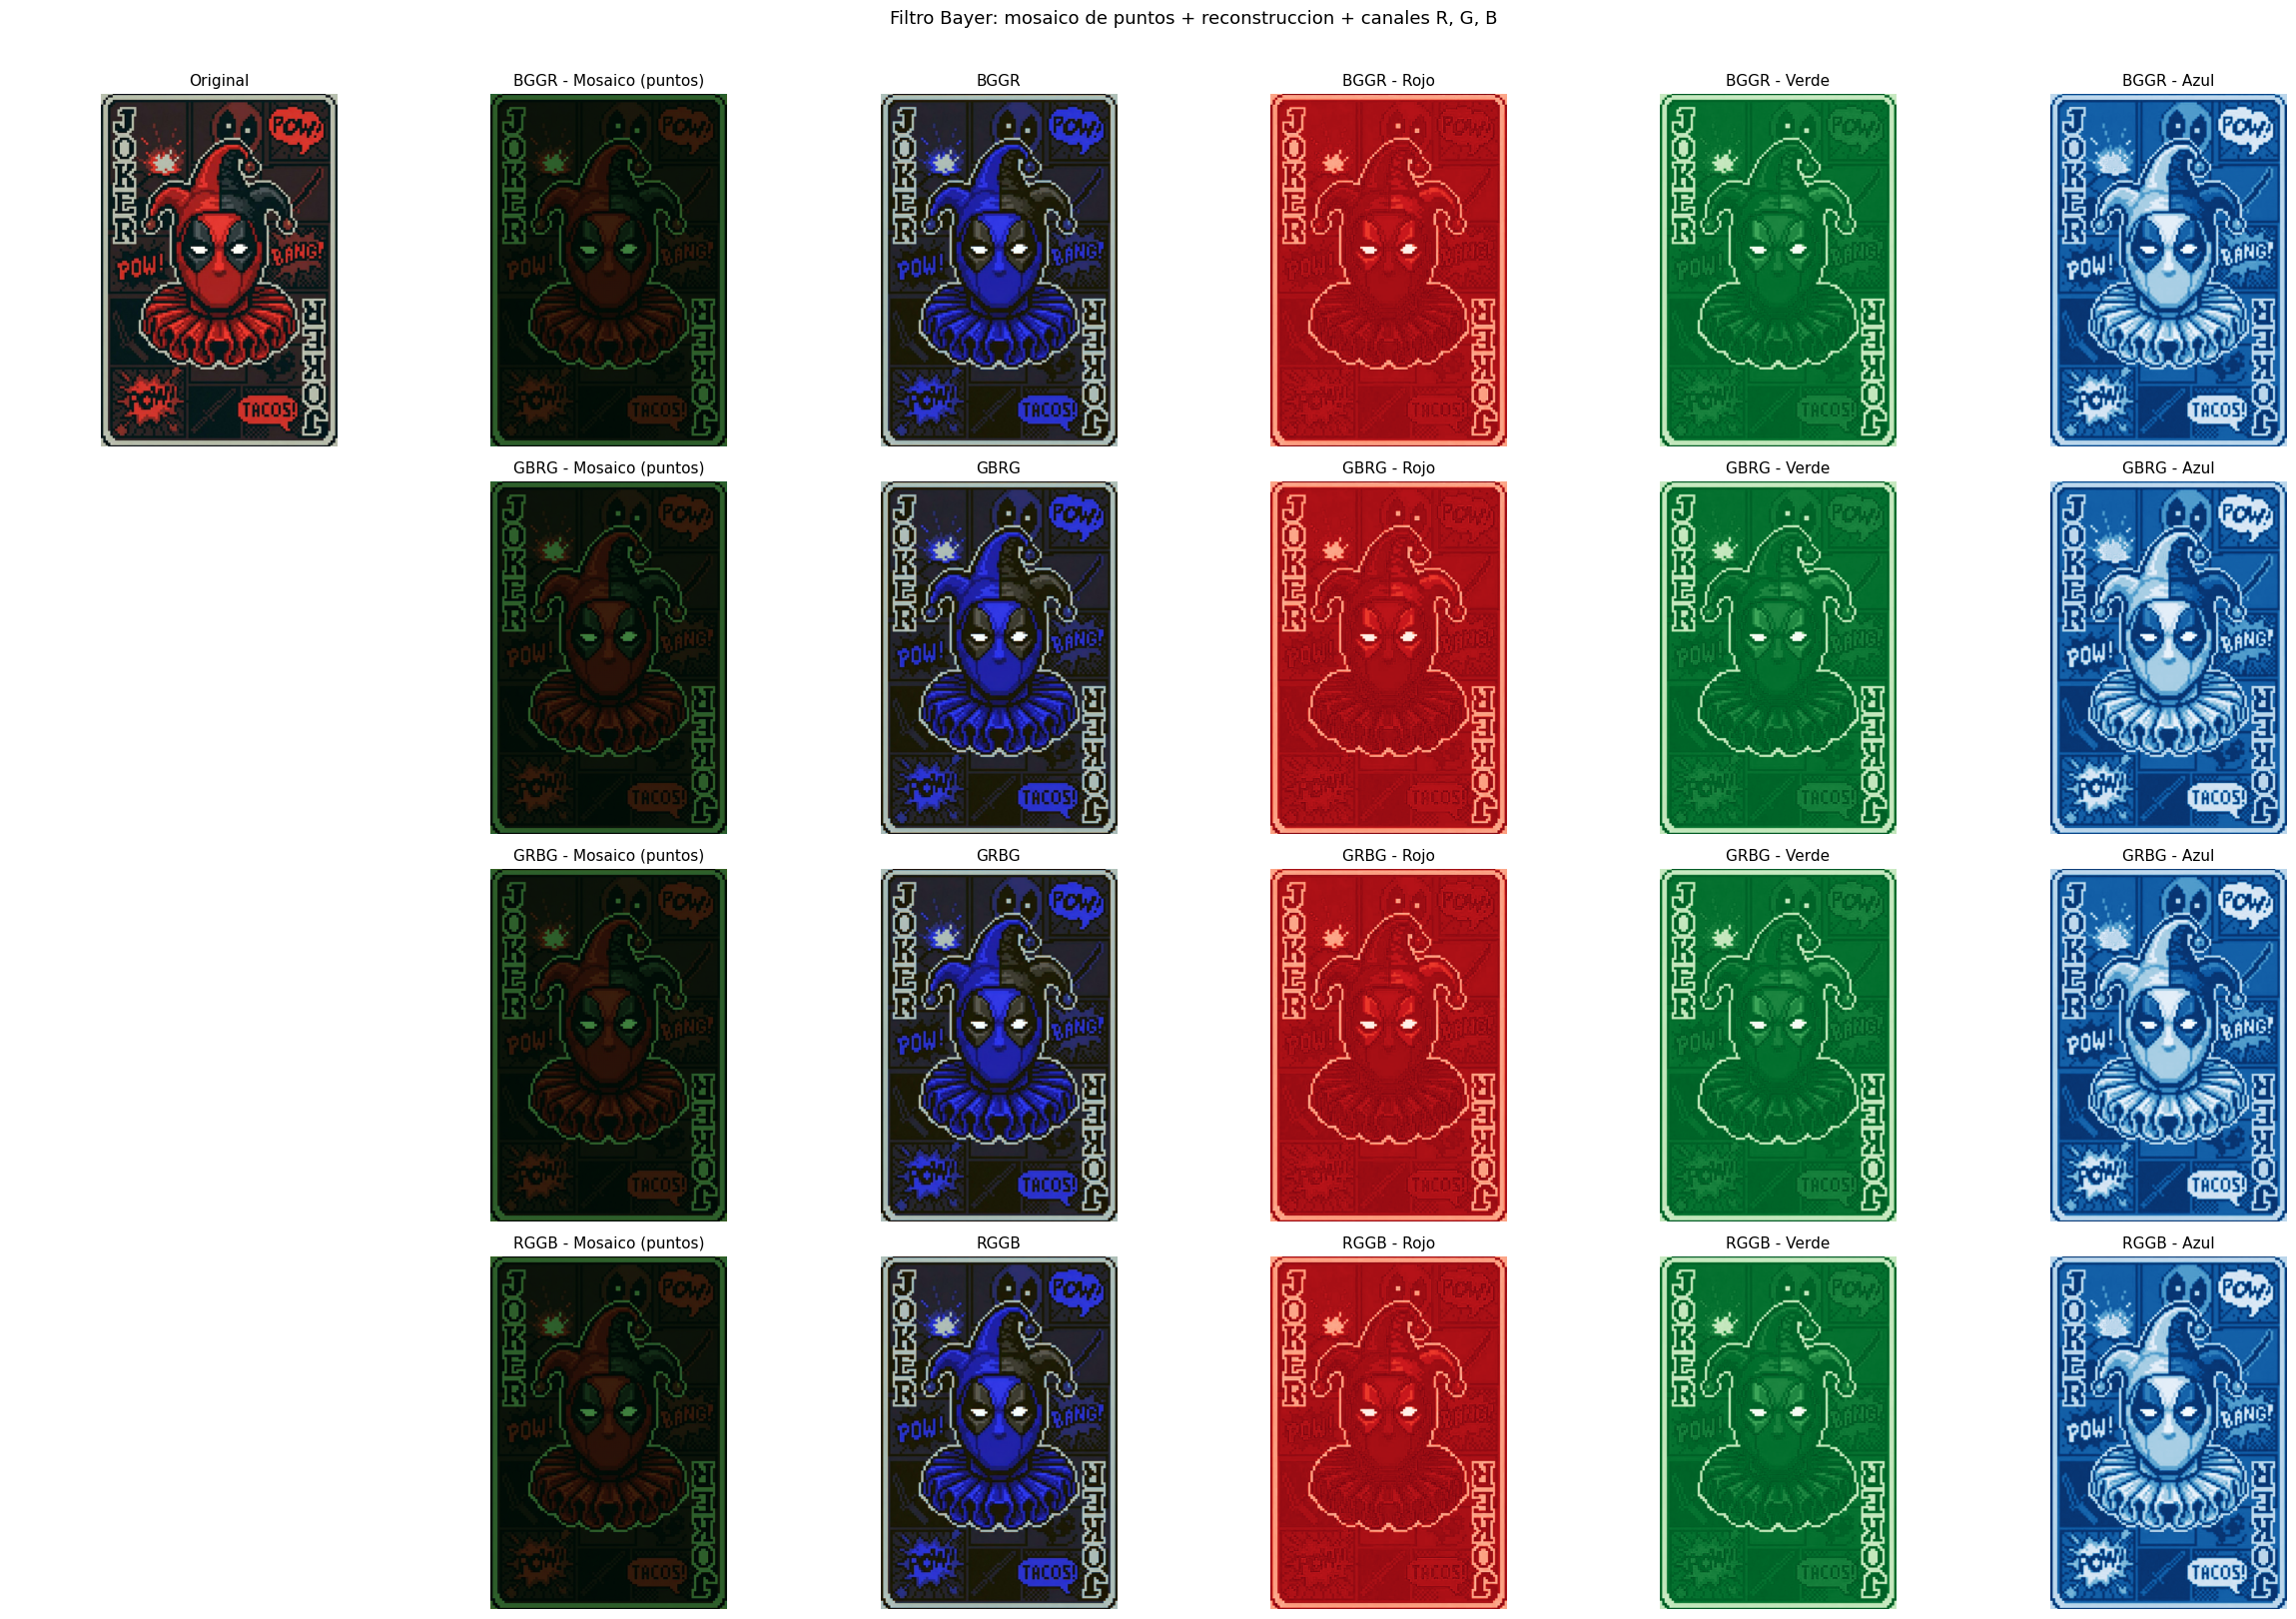

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ruta = '../clase2/deadpool.jpg'
imagen_bgr = cv2.imread(ruta, cv2.IMREAD_COLOR)

if imagen_bgr is None:
    raise FileNotFoundError(f'No se pudo cargar la imagen: {ruta}')

imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

versiones_bayer = [
    'COLOR_BayerRG2RGB',
    'COLOR_BayerBG2RGB',
    'COLOR_BayerGB2RGB',
    'COLOR_BayerGR2RGB',
    'COLOR_BayerRG2RGB_VNG',
    'COLOR_BayerRG2RGB_EA',
]

print('Imagen seleccionada:', ruta)
print('Versiones Bayer que se usaran en la practica:')
for nombre in versiones_bayer:
    print(nombre)


def crear_mosaico_bayer(img_bgr, patron='RG'):
    b, g, r = cv2.split(img_bgr)
    mosaico = np.zeros(img_bgr.shape[:2], dtype=img_bgr.dtype)

    if patron == 'RG':  
        mosaico[0::2, 0::2] = r[0::2, 0::2]
        mosaico[0::2, 1::2] = g[0::2, 1::2]
        mosaico[1::2, 0::2] = g[1::2, 0::2]
        mosaico[1::2, 1::2] = b[1::2, 1::2]
    elif patron == 'BG':  
        mosaico[0::2, 0::2] = b[0::2, 0::2]
        mosaico[0::2, 1::2] = g[0::2, 1::2]
        mosaico[1::2, 0::2] = g[1::2, 0::2]
        mosaico[1::2, 1::2] = r[1::2, 1::2]
    elif patron == 'GB': 
        mosaico[0::2, 0::2] = g[0::2, 0::2]
        mosaico[0::2, 1::2] = b[0::2, 1::2]
        mosaico[1::2, 0::2] = r[1::2, 0::2]
        mosaico[1::2, 1::2] = g[1::2, 1::2]
    elif patron == 'GR':  
        mosaico[0::2, 0::2] = g[0::2, 0::2]
        mosaico[0::2, 1::2] = r[0::2, 1::2]
        mosaico[1::2, 0::2] = b[1::2, 0::2]
        mosaico[1::2, 1::2] = g[1::2, 1::2]
    else:
        raise ValueError("sale error")

    return mosaico



def mosaico_a_color_puntos(img_bgr, patron='RG'):
    b, g, r = cv2.split(img_bgr)
    h, w = img_bgr.shape[:2]
    out = np.zeros((h, w, 3), dtype=img_bgr.dtype) 

    if patron == 'RG':  
        out[0::2, 0::2, 0] = r[0::2, 0::2]
        out[0::2, 1::2, 1] = g[0::2, 1::2]
        out[1::2, 0::2, 1] = g[1::2, 0::2]
        out[1::2, 1::2, 2] = b[1::2, 1::2]
    elif patron == 'BG':  
        out[0::2, 0::2, 2] = b[0::2, 0::2]
        out[0::2, 1::2, 1] = g[0::2, 1::2]
        out[1::2, 0::2, 1] = g[1::2, 0::2]
        out[1::2, 1::2, 0] = r[1::2, 1::2]
    elif patron == 'GB':  
        out[0::2, 0::2, 1] = g[0::2, 0::2]
        out[0::2, 1::2, 2] = b[0::2, 1::2]
        out[1::2, 0::2, 0] = r[1::2, 0::2]
        out[1::2, 1::2, 1] = g[1::2, 1::2]
    elif patron == 'GR':  
        out[0::2, 0::2, 1] = g[0::2, 0::2]
        out[0::2, 1::2, 0] = r[0::2, 1::2]
        out[1::2, 0::2, 2] = b[1::2, 0::2]
        out[1::2, 1::2, 1] = g[1::2, 1::2]
    else:
        raise ValueError("sale error")

    return out


patrones = [
    ('BGGR', 'BG', cv2.COLOR_BayerBG2RGB),
    ('GBRG', 'GB', cv2.COLOR_BayerGB2RGB),
    ('GRBG', 'GR', cv2.COLOR_BayerGR2RGB),
    ('RGGB', 'RG', cv2.COLOR_BayerRG2RGB),
]

fig, axes = plt.subplots(4, 6, figsize=(24, 16))

axes[0, 0].imshow(imagen_rgb)
axes[0, 0].set_title('Original', fontsize=11)
axes[0, 0].axis('off')
for fila in range(1, 4):
    axes[fila, 0].axis('off')

for fila, (nombre, patron, codigo) in enumerate(patrones):
    mosaico = crear_mosaico_bayer(imagen_bgr, patron)
    mosaico_color = mosaico_a_color_puntos(imagen_bgr, patron)
    rec = cv2.cvtColor(mosaico, codigo)
    r_ch, g_ch, b_ch = rec[:, :, 0], rec[:, :, 1], rec[:, :, 2]

    axes[fila, 1].imshow(mosaico_color)
    axes[fila, 1].set_title(f'{nombre} - Mosaico (puntos)', fontsize=11)
    axes[fila, 1].axis('off')

    

    axes[fila, 2].imshow(rec)
    axes[fila, 2].set_title(nombre, fontsize=11)
    axes[fila, 2].axis('off')

    axes[fila, 3].imshow(r_ch, cmap='Reds_r')
    axes[fila, 3].set_title(f'{nombre} - Rojo', fontsize=11)
    axes[fila, 3].axis('off')

    axes[fila, 4].imshow(g_ch, cmap='Greens_r')
    axes[fila, 4].set_title(f'{nombre} - Verde', fontsize=11)
    axes[fila, 4].axis('off')

    axes[fila, 5].imshow(b_ch, cmap='Blues_r')
    axes[fila, 5].set_title(f'{nombre} - Azul', fontsize=11)
    axes[fila, 5].axis('off')

plt.suptitle('Filtro Bayer: mosaico de puntos + reconstruccion + canales R, G, B', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

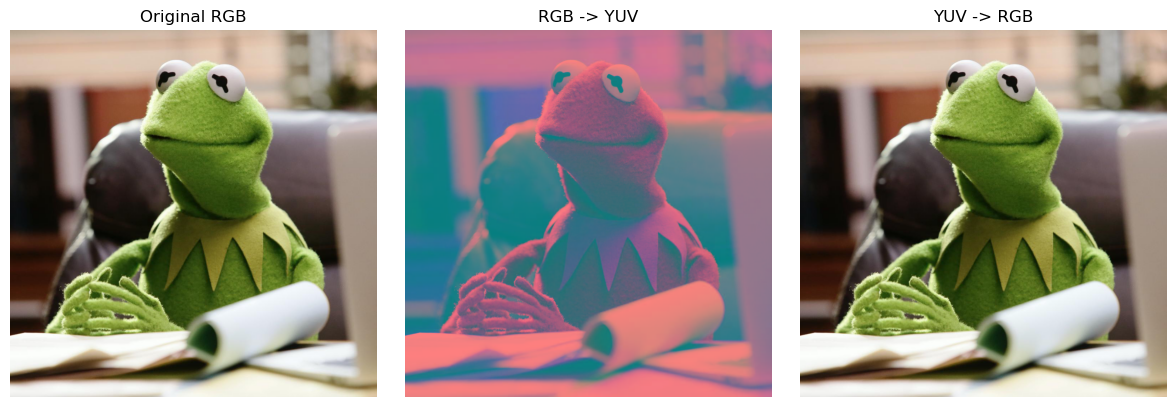

MAE RGB -> YUV -> RGB: 0.2954


In [9]:
rgb = imagen_rgb.copy()

yuv = cv2.cvtColor(rgb, cv2.COLOR_RGB2YUV)
rgb_recuperada = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb)
plt.title('Original RGB')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(yuv)
plt.title('RGB -> YUV')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(rgb_recuperada)
plt.title('YUV -> RGB')
plt.axis('off')

plt.tight_layout()
plt.show()

mae = np.mean(np.abs(rgb.astype(np.int16) - rgb_recuperada.astype(np.int16)))
print(f'MAE RGB -> YUV -> RGB: {mae:.4f}')